# 00. 全体像 — フーリエ解析は「波で関数を読み解く言語」

この教材は、フーリエ解析を **関数を直交する波の基底で展開する理論** として学ぶ
Jupyter Notebook 教科書です。単なる FFT 入門や信号処理のレシピ集ではありません。
中心にあるのは次の見方です。

> 複雑な関数や信号を、単純な振動成分に分解し、
> **構造・エネルギー・滑らかさ・時間変化** を読み解く。

定義から始めません。まず「なぜ波に分解したいのか」「分解すると何が見えるのか」
から入り、現象 → 直感 → 可視化 → 数式 → Python 実験 → 応用 → 発展 の順に進みます。

## なぜ波に分解するのか

正弦波は「最も単純な振動」です。複雑に見える信号も、周波数の違う正弦波を
足し合わせたものとして表せます。波に分解すると、時間の波形を眺めていては
見えない構造が見えてきます。

- **構造**: どの周波数成分が含まれるか(和音・周期・トレンド)
- **エネルギー**: 各成分にどれだけのエネルギーがあるか(Parseval)
- **滑らかさ**: 滑らかな関数ほど高周波成分が速く小さくなる
- **時間変化**: 周波数が時間とともにどう変わるか(STFT)

## 時間領域と周波数領域

同じ信号を 2 通りに見ます。**時間領域**(横軸 = 時刻)では「いつ何が起きたか」、
**周波数領域**(横軸 = 周波数)では「どの振動がどれだけ含まれるか」が見えます。
下の図は、3 つの正弦波を足した信号(左)と、その振幅スペクトル(右)です。
左の波形からは読み取りにくい「3 本の周波数成分」が、右にははっきり立ちます。

In [1]:
# Shared setup: make fourier_book importable, fix seeds, inline rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import fourier_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "fourier_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import matplotlib.pyplot as plt
import numpy as np

from fourier_book import datasets, filters, plotting, signals, spectral, transforms, widgets

np.set_printoptions(precision=3, suppress=True)

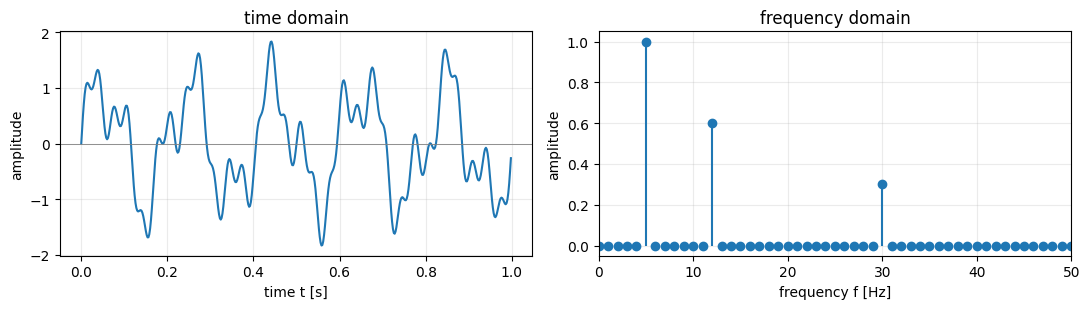

In [2]:
# A signal built from three pure tones, viewed in both domains.
fs = 500.0
t, x = datasets.make_multitone(fs=fs, duration=1.0, freqs=(5, 12, 30), amps=(1.0, 0.6, 0.3))
freqs, amp = transforms.amplitude_spectrum(x, fs)
plotting.plot_time_and_freq(t, x, freqs, amp, xlim_freq=(0, 50))
plt.show()

## フーリエ級数・フーリエ変換・DFT・FFT の違い

| 道具 | 対象 | 周波数 | 式の中心 |
|---|---|---|---|
| フーリエ級数 | **周期**関数 | 離散(整数倍音) | $f(x)=\sum_n c_n e^{inx}$ |
| フーリエ変換 | **非周期**関数 | 連続スペクトル | $\hat f(\xi)=\int f(x)e^{-2\pi i x\xi}dx$ |
| DFT | **有限個**の標本 | 離散ビン | $X_k=\sum_n x_n e^{-2\pi i kn/N}$ |
| FFT | DFT と同じ | 同じ | DFT を $O(N\log N)$ で計算する**アルゴリズム** |

級数は「周期関数を倍音の和に」、変換は「非周期関数を連続スペクトルに」、
DFT は「有限データを離散周波数に」分けます。FFT は DFT の高速計算法であって、
別の変換ではありません。

## 線形代数・微分積分・PDE との接続

本書を貫く一番大事な見方は **「フーリエ解析は関数版の線形代数」** です。

- 正弦波・余弦波・複素指数関数 $e^{inx}$ は、関数空間の **基底** のように働く
- 関数の内積 $\langle f,g\rangle=\int f\overline{g}\,dx$ で「成分の大きさ」を測る
- フーリエ係数は、関数を各基底方向へ **射影** した成分
- 微分は周波数領域では $ik$ 倍 → PDE はモードごとに分離される(08 章)

線形代数(`analytics/linear_algebra`)の内積・正射影・固有値分解を知っていると、
本書の見通しが一気に良くなります。

## この教材の読み方 / 3 層構成

各 Notebook は原則として **Big Picture → Problem → Intuition → Visualization →
Definition → Computation → Invariant/Energy → Failure Mode → Application →
Exercises → Advanced Notes** の流れで構成されます。各章には 3 つの層を入れています。

- **Basic**: 初学者が最低限理解すべき内容
- **Applied**: Python 実装・応用例
- **Advanced**: 証明・発展理論・実務上の注意(厳密な収束条件などはここに分離)

### 章構成

| Notebook | 内容 |
|---|---|
| `00_overview` | 全体像・時間/周波数領域・読み方・環境準備 |
| `01_waves_complex_numbers_inner_products` | 正弦波・複素指数・関数の内積・直交性 |
| `02_fourier_series_periodic_functions` | フーリエ級数・矩形波・Gibbs 現象 |
| `03_convergence_energy_parseval` | 収束・エネルギー・Parseval・係数減衰 |
| `04_fourier_transform_nonperiodic_functions` | フーリエ変換・不確定性 |
| `05_convolution_filtering_distributions` | 畳み込み・フィルタ・畳み込み定理 |
| `06_dft_fft_sampling_aliasing` | DFT/FFT・標本化・aliasing・窓関数 |
| `07_time_frequency_stft_wavelets_intro` | STFT・スペクトログラム・wavelet 入口 |
| `08_pde_spectral_methods` | 熱・波動方程式・スペクトル法 |
| `09_applications_signal_image_finance_ml` | 音・画像 2D FFT・金融時系列・ML |

### Python 環境の準備

リポジトリルート `~/projects` の uv workspace を使う場合:

```bash
cd ~/projects
make install          # = uv sync --all-packages(fourier を members に追加後)
uv run jupyter lab analytics/fourier/notebooks/
```

単体で使う場合は `analytics/fourier/README.md` を参照してください。
共通関数はすべて `src/fourier_book/` にあり、上の setup セルで読み込んでいます。

## まとめ

- フーリエ解析は、関数を **直交する波の基底** で展開する理論
- 時間領域と周波数領域は同じ信号の二つの顔
- 級数 / 変換 / DFT は「対象」が違うだけ、FFT は DFT の高速計算法
- 次章 `01` では、その基底となる **正弦波・複素指数・内積・直交性** を作る